In [216]:
!pip install snowflake-connector-python

In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [218]:
import snowflake.connector
con = snowflake.connector.connect(
		 user ='Hemantth',
	  password='Karpagam123---',
		account = 'QJWJXYO-DW29303',
						database='TITANIC',
						schema = 'PUBLIC',
						warehouse = 'COMPUTE_WH',
);

In [219]:
query="SELECT * FROM titanic"
df=pd.read_sql(query,con)
con.close()
df

/tmp/ipykernel_8964/2638353121.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PASSENGERID  891 non-null    int64  
 1   SURVIVED     891 non-null    int64  
 2   PCLASS       891 non-null    int64  
 3   NAME         891 non-null    object 
 4   SEX          891 non-null    object 
 5   AGE          714 non-null    float64
 6   SIBSP        891 non-null    int64  
 7   PARCH        891 non-null    int64  
 8   TICKET       891 non-null    object 
 9   FARE         891 non-null    float64
 10  CABIN        204 non-null    object 
 11  EMBARKED     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [221]:
df.isna().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,177
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [222]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
imr=SimpleImputer(strategy='most_frequent')
df[['AGE']]=imp.fit_transform(df[['AGE']])
#df[['CABIN']]=imr.fit_transform(df[['CABIN']])
df[['EMBARKED']]=imr.fit_transform(df[['EMBARKED']])

In [223]:
df

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,None,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [224]:
df=df.drop('CABIN',axis=1)
df=df.drop('NAME',axis=1)
df=df.drop('TICKET',axis=1)

In [225]:
df.isna().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
FARE,0
EMBARKED,2


In [226]:
from sklearn.impute import SimpleImputer
imr=SimpleImputer(strategy='most_frequent')
df[['EMBARKED']]=imr.fit_transform(df[['EMBARKED']])

In [227]:
df.isna().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
FARE,0
EMBARKED,2


In [228]:
df['EMBARKED'] = df['EMBARKED'].fillna(df['EMBARKED'].mode()[0])


In [229]:
df.isna().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
FARE,0
EMBARKED,0


In [230]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['SEX']=le.fit_transform(df['SEX'])
df['EMBARKED']=le.fit_transform(df['EMBARKED'])
df

,PASSENGERID,SURVIVED,PCLASS,SEX,AGE,SIBSP,PARCH,FARE,EMBARKED
0,1,0,3,1,22.000000,1,0,7.2500,2
1,2,1,1,0,38.000000,1,0,71.2833,0
2,3,1,3,0,26.000000,0,0,7.9250,2
3,4,1,1,0,35.000000,1,0,53.1000,2
4,5,0,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0,0,13.0000,2
887,888,1,1,0,19.000000,0,0,30.0000,2
888,889,0,3,0,29.699118,1,2,23.4500,2
889,890,1,1,1,26.000000,0,0,30.0000,0


/tmp/ipykernel_8964/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


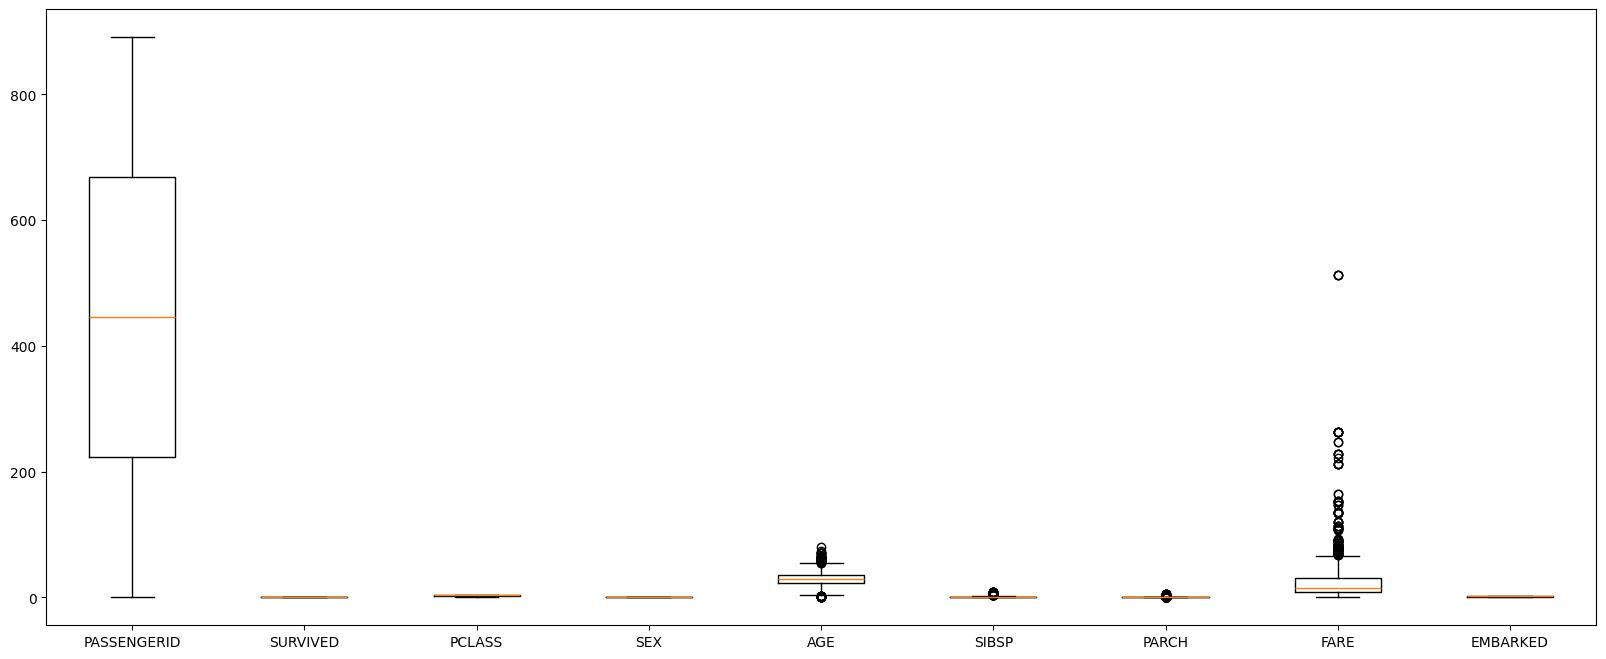

In [231]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [232]:
n=df.select_dtypes(include=['float64','int64']).columns.tolist()
for col in n:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df[col]=df[col].clip(lower,upper)
df

,PASSENGERID,SURVIVED,PCLASS,SEX,AGE,SIBSP,PARCH,FARE,EMBARKED
0,1,0,3,1,22.000000,1.0,0,7.2500,2
1,2,1,1,0,38.000000,1.0,0,65.6344,0
2,3,1,3,0,26.000000,0.0,0,7.9250,2
3,4,1,1,0,35.000000,1.0,0,53.1000,2
4,5,0,3,1,35.000000,0.0,0,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,0.0,0,13.0000,2
887,888,1,1,0,19.000000,0.0,0,30.0000,2
888,889,0,3,0,29.699118,1.0,0,23.4500,2
889,890,1,1,1,26.000000,0.0,0,30.0000,0


/tmp/ipykernel_8964/160573771.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n.values,labels=n.columns)


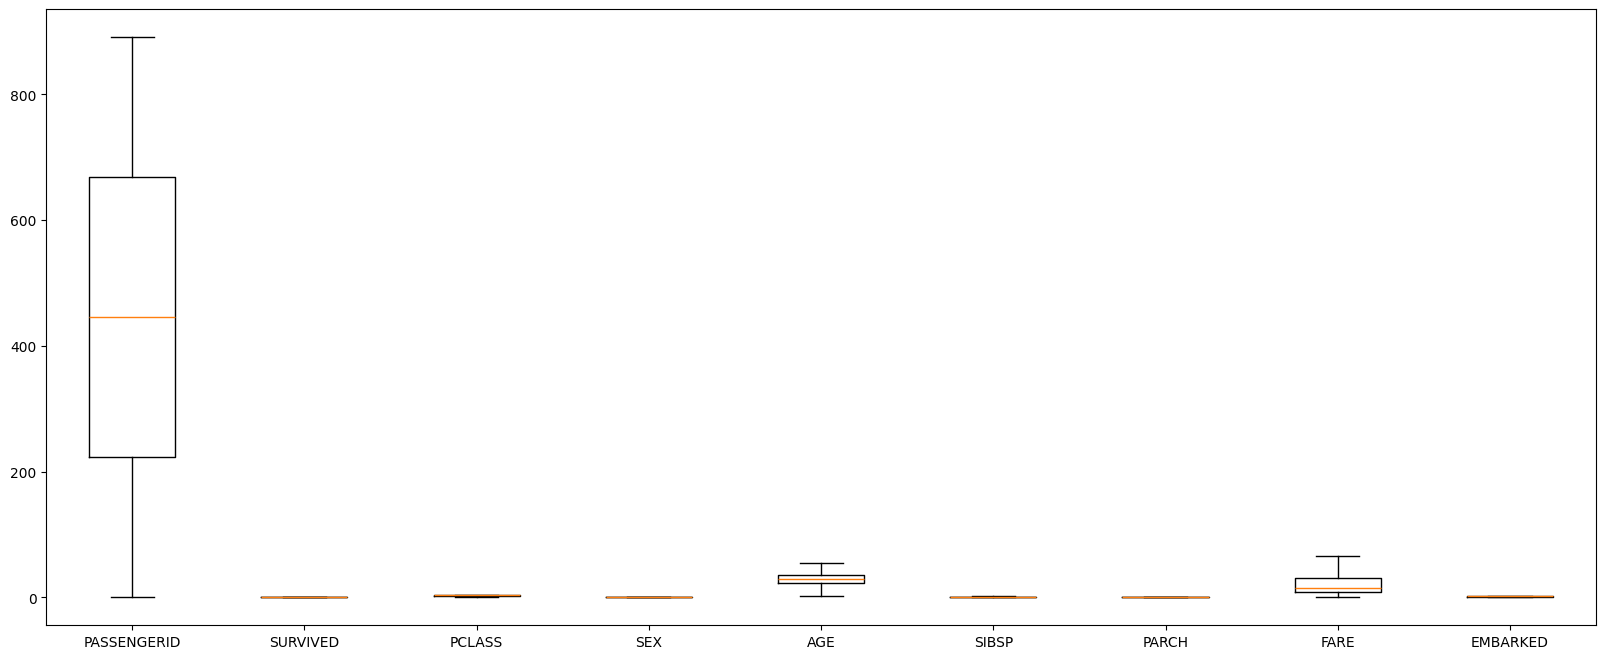

In [233]:
n=df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(20,8))
plt.boxplot(n.values,labels=n.columns)
plt.show()

In [234]:
dfn=df.columns.tolist()
dfn

['PASSENGERID',
 'SURVIVED',
 'PCLASS',
 'SEX',
 'AGE',
 'SIBSP',
 'PARCH',
 'FARE',
 'EMBARKED']

In [235]:
X=df[['PASSENGERID',
 'PCLASS',

 'SEX',
 'AGE',
 'SIBSP',
 'PARCH',

 'FARE',
 'EMBARKED']]
y=df['SURVIVED']

In [236]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [237]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("OOB Score :", model.oob_score_)

Accuracy : 0.8156424581005587
OOB Score : 0.8132022471910112


In [238]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=7
)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.6480446927374302
